In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from SynOmics.metrics.narrow_utility.BayesianComparison import BayesianComparison 

cancers = ['ccRCC', 'Melanoma', 'NSCLC']
seeds = [42,0,1,2,3]
names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']

ssGSEA_Score_Dict = {}
for cancer in cancers:
    score_dict = {}
    for i, name in enumerate(names):
        methods_score = []
        for seed in seeds:
            datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}',f'ctgan_{seed}',f'gaussiancopula_{seed}',f'synthpop_{seed}',f'tvae_{seed}']
            uni_clinical_df = pd.read_csv(f'../{cancer}/NarrowUtility/ssGSEA/KSStatistic/Seed_{seed}/Detail_score_{datasets[i]}.csv')
            score_ssgsea_1_seed = np.mean(uni_clinical_df["Score"].fillna(0).tolist())
            methods_score.append(score_ssgsea_1_seed)
            
        score_dict[name] = methods_score
    ssGSEA_Score_Dict[cancer] = score_dict

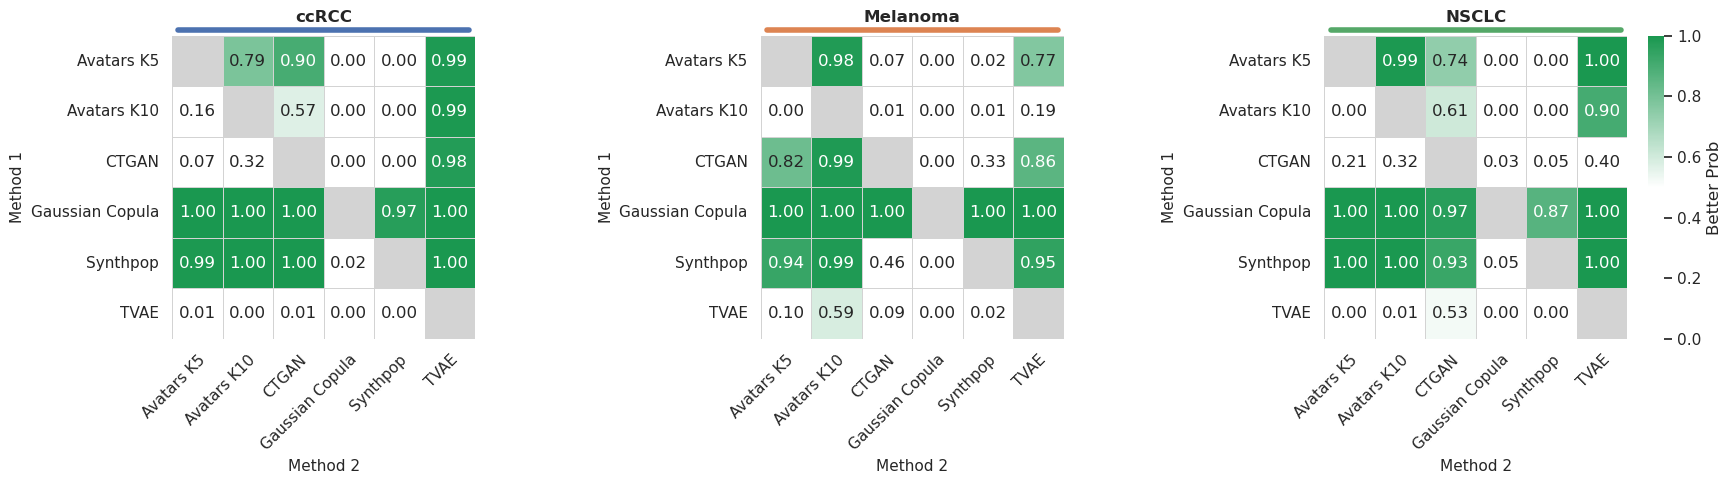

In [3]:
bc = BayesianComparison(rope=0.01)
methods_order = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
fig, axes, mats_by_cancer, comps_by_cancer = bc.plot_pbetter_heatmap_grid(
    cancer_to_method_scores=ssGSEA_Score_Dict,
    cancers_order=("ccRCC", "Melanoma", "NSCLC"),
    methods_order=methods_order,
    value_col="Better Prob",
    figsize = (18,5),
    annot=True,
    fmt=".2f",
    show=True,
)

fig.savefig("bayesian_comp_fig6b_ksc.pdf", bbox_inches="tight", facecolor="white")
for cancer in cancers:
    bayesian_comp_df = comps_by_cancer[cancer]
    bayesian_comp_df.to_csv(f'KS_ssGSEA_Bayesian_{cancer}.csv')